# Multi-Experiment Benchmark: Causal vs Traditional Models

This notebook runs **4 experiments** (A2C, B1C, C2C, D2C) with diverse DGPs (linear, nonlinear polynomial, trigonometric+trend),
evaluates causal vs traditional ML models on both **observational test sets** and **point-wise interventions**,
then aggregates results across experiments using **normalized metrics** (NRMSE, NMAE) to produce a
final median summary per model type and algorithm.

**Experiments:**
- **A2C**: 6 variables, 2 lags, linear with confounder
- **B1C**: 4 variables, 4 lags, nonlinear polynomial with confounder
- **C2C**: 6 variables, 4 lags, trigonometric + trend + seasonality (no confounder)
- **D2C**: 8 variables, 4 lags, nonlinear polynomial with confounder

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from pygam import LinearGAM, s
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from pathlib import Path
from scipy import stats

import utils as ut
import model_wrappers as mw

current_path = Path(__file__).resolve().parent if '__file__' in globals() else Path().resolve()
print("Setup complete.")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Setup complete.


## 1. Experiment Registry

Each experiment is defined by its equations (as text), number of variables, max lag,
target variable, and intervention variable.

In [2]:
EXPERIMENTS = {
    "A2C": {
        "description": "Linear, 6 variables, 2 lags, confounder U",
        "n_vars": 6,
        "max_lag": 2,
        "target_var": "X2",
        "intervene_var": "X3",
        "equations": [
            "X6[t] = 0.85 * X5[t] + 0.4 * U[t] + e6",
            "X5[t] = e5",
            "X4[t] = 0.25 * X1[t-2] + 0.3 * X5[t-1] + e4",
            "X3[t] = 0.35 * X4[t] + 0.3 * U[t] + e3",
            "X2[t] = 0.3 * X3[t-1] + e2",
            "X1[t] = 0.4 * X2[t] + 0.5 * U[t] + e1",
            "U[t] = eU",
        ],
    },
    "B1C": {
        "description": "Nonlinear polynomial, 4 variables, 4 lags, confounder U",
        "n_vars": 4,
        "max_lag": 4,
        "target_var": "X2",
        "intervene_var": "X3",
        "equations": [
            "X4[t] = 0.25 * X1[t-4]^2 - 0.1 * X1[t-4]^3 + e4",
            "X3[t] = 0.35 * X4[t]^2 - 0.15 * X4[t]^3 + 0.2 * X2[t-3]^2 + 0.3 * U[t]^2 + e3",
            "X2[t] = 0.3 * X3[t-1]^2 - 0.05 * X3[t-1]^3 + e2",
            "X1[t] = 0.4 * X2[t]^2 - 0.2 * X2[t]^3 + 0.5 * U[t]^2 + e1",
            "U[t] = eU",
        ],
    },
    "C2C": {
        "description": "Trigonometric + trend + seasonality, 6 variables, 4 lags, no confounder",
        "n_vars": 6,
        "max_lag": 4,
        "target_var": "X2",
        "intervene_var": "X3",
        "equations": [
            "X4[t] = 0.25 * cos(X1[t-4] * pi/2) + trend4[t] + season4[t] + e4",
            "X3[t] = 0.35 * (X4[t])^2 + 0.2 * cos(X2[t-3] * pi/2) + trend3[t] + season3[t] + e3",
            "X2[t] = 0.3 * sin(X3[t-1] * pi/2) + trend2[t] + season2[t] + e2",
            "X1[t] = 0.4 * (X2[t])^3 + trend1[t] + season1[t] + e1",
            "X6[t] = 0.45 * sin(X5[t] * pi/2) + trend6[t] + season6[t] + e6",
            "X5[t] = 0.3 * cos(X4[t-1] * pi/2) + trend5[t] + season5[t] + e5",
        ],
    },
    "D2C": {
        "description": "Nonlinear polynomial, 8 variables, 4 lags, confounder U",
        "n_vars": 8,
        "max_lag": 4,
        "target_var": "X2",
        "intervene_var": "X3",
        "equations": [
            "X8[t] = 0.4 * X7[t]^2 - 0.12 * X7[t]^3 + e8",
            "X7[t] = 0.35 * X6[t-1]^2 - 0.08 * X6[t-1]^3 + e7",
            "X6[t] = 0.85 * X5[t]^2 - 0.15 * X5[t]^3 + e6",
            "X5[t] = 0.3 * X4[t-1]^2 - 0.1 * X4[t-1]^3 + e5",
            "X4[t] = 0.25 * X1[t-4]^2 - 0.1 * X1[t-4]^3 + e4",
            "X3[t] = 0.35 * X4[t]^2 - 0.15 * X4[t]^3 + 0.2 * X2[t-3]^2 + 0.3 * U[t]^2 + e3",
            "X2[t] = 0.3 * X3[t-1]^2 - 0.05 * X3[t-1]^3 + e2",
            "X1[t] = 0.4 * X2[t]^2 - 0.2 * X2[t]^3 + 0.5 * U[t]^2 + e1",
            "U[t] = eU",
        ],
    },
}

for name, exp in EXPERIMENTS.items():
    print(f"\n{name}: {exp['description']}")
    print(f"  n_vars={exp['n_vars']}, max_lag={exp['max_lag']}")
    print(f"  target={exp['target_var']}, intervene={exp['intervene_var']}")
    for eq in exp['equations']:
        print(f"    {eq}")


A2C: Linear, 6 variables, 2 lags, confounder U
  n_vars=6, max_lag=2
  target=X2, intervene=X3
    X6[t] = 0.85 * X5[t] + 0.4 * U[t] + e6
    X5[t] = e5
    X4[t] = 0.25 * X1[t-2] + 0.3 * X5[t-1] + e4
    X3[t] = 0.35 * X4[t] + 0.3 * U[t] + e3
    X2[t] = 0.3 * X3[t-1] + e2
    X1[t] = 0.4 * X2[t] + 0.5 * U[t] + e1
    U[t] = eU

B1C: Nonlinear polynomial, 4 variables, 4 lags, confounder U
  n_vars=4, max_lag=4
  target=X2, intervene=X3
    X4[t] = 0.25 * X1[t-4]^2 - 0.1 * X1[t-4]^3 + e4
    X3[t] = 0.35 * X4[t]^2 - 0.15 * X4[t]^3 + 0.2 * X2[t-3]^2 + 0.3 * U[t]^2 + e3
    X2[t] = 0.3 * X3[t-1]^2 - 0.05 * X3[t-1]^3 + e2
    X1[t] = 0.4 * X2[t]^2 - 0.2 * X2[t]^3 + 0.5 * U[t]^2 + e1
    U[t] = eU

C2C: Trigonometric + trend + seasonality, 6 variables, 4 lags, no confounder
  n_vars=6, max_lag=4
  target=X2, intervene=X3
    X4[t] = 0.25 * cos(X1[t-4] * pi/2) + trend4[t] + season4[t] + e4
    X3[t] = 0.35 * (X4[t])^2 + 0.2 * cos(X2[t-3] * pi/2) + trend3[t] + season3[t] + e3
    X2[t] = 0.

## 2. Global Configuration

In [3]:
N_POINTS = 6000
TRAIN_RATIO = 4000 / 6000
RANDOM_STATE = 42
N_INTERVENTIONS = 2000
NOISE_SCALE = 0.1

print(f"Points per experiment: {N_POINTS}")
print(f"Train/Test split: {int(N_POINTS * TRAIN_RATIO)} / {int(N_POINTS * (1 - TRAIN_RATIO))}")
print(f"Interventions per experiment: {N_INTERVENTIONS}")

Points per experiment: 6000
Train/Test split: 4000 / 2000
Interventions per experiment: 2000


## 3. Universal Equation Parser & DGP

Handles linear terms, polynomial terms (`^2`, `^3`), trigonometric terms (`sin`, `cos`),
and trend/seasonality components.

In [4]:
def parse_equations(equations):
    """
    Parse equation strings into structured causal terms.
    Returns:
        parsed: dict {target_var: list of term dicts}
        causal_links: dict {(source, lag, target): coeff}  (for graph building)
    
    Each term dict has: coeff, source, lag, power, func (None, 'sin', 'cos'),
                        func_scale (e.g. pi/2), is_trend, is_season
    """
    parsed = {}
    causal_links = {}
    
    for eq in equations:
        if '=' not in eq:
            continue
        left, right = [s.strip() for s in eq.split('=', 1)]
        target = left.split('[')[0].strip()
        
        # Pure noise equation
        right_stripped = right.strip()
        if re.match(r'^e\w+$', right_stripped):
            parsed[target] = [{'type': 'noise_only'}]
            continue
        
        terms_list = []
        # Split on + and - while keeping sign
        raw_terms = re.split(r'(?=[+-])', right.replace('- ', '+ -'))
        raw_terms = [t.strip() for t in raw_terms if t.strip()]
        
        for term_str in raw_terms:
            term_str = term_str.strip().lstrip('+')
            term_str = term_str.strip()
            
            if not term_str:
                continue
            
            # Skip noise terms like 'e4', 'e3'
            if re.match(r'^-?\s*e\w+$', term_str):
                continue
            
            # Check for trend/season
            trend_match = re.match(r'^trend(\d+)\[t\]$', term_str)
            season_match = re.match(r'^season(\d+)\[t\]$', term_str)
            if trend_match:
                terms_list.append({'type': 'trend', 'var_idx': int(trend_match.group(1))})
                continue
            if season_match:
                terms_list.append({'type': 'season', 'var_idx': int(season_match.group(1))})
                continue
            
            # Pattern: coeff * func(var[t-lag] * scale)^power  OR  coeff * var[t-lag]^power
            # Try trig pattern first: coeff * sin/cos(var[t-lag] * pi/2)
            trig_match = re.match(
                r'^([\d.\-]+)\s*\*\s*(sin|cos)\(([A-Za-z]\w*)\[([^\]]+)\]\s*\*?\s*([^)]*)?\)',
                term_str
            )
            if trig_match:
                coeff = float(trig_match.group(1))
                func = trig_match.group(2)
                source = trig_match.group(3)
                lag_str = trig_match.group(4).strip()
                lag = 0 if lag_str == 't' else int(lag_str.split('-')[1])
                terms_list.append({
                    'type': 'trig', 'coeff': coeff, 'func': func,
                    'source': source, 'lag': lag
                })
                causal_links[(source, lag, target)] = coeff
                continue
            
            # Try polynomial with parenthesized variable: coeff * (var[t-lag])^power
            paren_poly_match = re.match(
                r'^([\d.\-]+)\s*\*\s*\(([A-Za-z]\w*)\[([^\]]+)\]\)\^(\d+)',
                term_str
            )
            if paren_poly_match:
                coeff = float(paren_poly_match.group(1))
                source = paren_poly_match.group(2)
                lag_str = paren_poly_match.group(3).strip()
                lag = 0 if lag_str == 't' else int(lag_str.split('-')[1])
                power = int(paren_poly_match.group(4))
                terms_list.append({
                    'type': 'poly', 'coeff': coeff, 'source': source,
                    'lag': lag, 'power': power
                })
                if (source, lag, target) not in causal_links:
                    causal_links[(source, lag, target)] = coeff
                continue
            
            # Try polynomial: coeff * var[t-lag]^power
            poly_match = re.match(
                r'^([\d.\-]+)\s*\*\s*([A-Za-z]\w*)\[([^\]]+)\]\^(\d+)',
                term_str
            )
            if poly_match:
                coeff = float(poly_match.group(1))
                source = poly_match.group(2)
                lag_str = poly_match.group(3).strip()
                lag = 0 if lag_str == 't' else int(lag_str.split('-')[1])
                power = int(poly_match.group(4))
                terms_list.append({
                    'type': 'poly', 'coeff': coeff, 'source': source,
                    'lag': lag, 'power': power
                })
                if (source, lag, target) not in causal_links:
                    causal_links[(source, lag, target)] = coeff
                continue
            
            # Try linear: coeff * var[t-lag]
            linear_match = re.match(
                r'^([\d.\-]+)\s*\*\s*([A-Za-z]\w*)\[([^\]]+)\]$',
                term_str
            )
            if linear_match:
                coeff = float(linear_match.group(1))
                source = linear_match.group(2)
                lag_str = linear_match.group(3).strip()
                lag = 0 if lag_str == 't' else int(lag_str.split('-')[1])
                terms_list.append({
                    'type': 'linear', 'coeff': coeff, 'source': source,
                    'lag': lag
                })
                causal_links[(source, lag, target)] = coeff
                continue
        
        parsed[target] = terms_list
    
    return parsed, causal_links


# Test parser on each experiment
for name, exp in EXPERIMENTS.items():
    parsed, links = parse_equations(exp['equations'])
    print(f"\n{name}: {len(links)} causal links")
    for k, v in links.items():
        print(f"  {k[0]}[t-{k[1]}] -> {k[2]}: {v}")


A2C: 6 causal links
  X5[t-0] -> X6: 0.85
  U[t-0] -> X6: 0.4
  X4[t-0] -> X3: 0.35
  U[t-0] -> X3: 0.3
  X2[t-0] -> X1: 0.4
  U[t-0] -> X1: 0.5

B1C: 4 causal links
  X4[t-0] -> X3: 0.35
  U[t-0] -> X3: 0.3
  X2[t-0] -> X1: 0.4
  U[t-0] -> X1: 0.5

C2C: 3 causal links
  X4[t-0] -> X3: 0.35
  X2[t-0] -> X1: 0.4
  X5[t-0] -> X6: 0.45

D2C: 6 causal links
  X7[t-0] -> X8: 0.4
  X5[t-0] -> X6: 0.85
  X4[t-0] -> X3: 0.35
  U[t-0] -> X3: 0.3
  X2[t-0] -> X1: 0.4
  U[t-0] -> X1: 0.5


In [5]:
class UniversalTimeSeriesGenerator:
    """Generates time series from arbitrary SCM equations (linear, polynomial, trig, trend/season)."""
    
    def __init__(self, noise_scale=0.1, random_state=None):
        self.noise_scale = noise_scale
        self.random_state = random_state
    
    def generate(self, n_points, equations, n_vars, max_lag):
        if self.random_state is not None:
            np.random.seed(self.random_state)
        
        parsed, _ = parse_equations(equations)
        has_U = 'U' in parsed
        
        X = np.zeros((n_points, n_vars))
        U = np.zeros(n_points)
        
        # Pre-generate trend and seasonality components
        trends = {}
        seasons = {}
        for i in range(1, n_vars + 1):
            trends[i] = 0.001 * np.arange(n_points)  # gentle linear trend
            seasons[i] = 0.1 * np.sin(2 * np.pi * np.arange(n_points) / 50)  # period=50
        
        # Initialize first max_lag rows with noise
        for t in range(max_lag):
            X[t] = np.random.normal(0, self.noise_scale, n_vars)
            U[t] = np.random.normal(0, self.noise_scale)
        
        # Generate step by step
        for t in range(max_lag, n_points):
            noise = np.random.normal(0, self.noise_scale, n_vars + 1)
            U[t] = noise[-1]  # confounder is pure noise
            
            for i in range(n_vars):
                var_name = f'X{i+1}'
                if var_name not in parsed:
                    X[t, i] = noise[i]
                    continue
                
                terms = parsed[var_name]
                
                # Noise-only variable
                if len(terms) == 1 and terms[0].get('type') == 'noise_only':
                    X[t, i] = noise[i]
                    continue
                
                value = 0.0
                for term in terms:
                    ttype = term['type']
                    if ttype == 'trend':
                        value += trends[term['var_idx']][t]
                    elif ttype == 'season':
                        value += seasons[term['var_idx']][t]
                    else:
                        # Get source value
                        source = term['source']
                        lag = term['lag']
                        if source == 'U':
                            src_val = U[t] if lag == 0 else U[t - lag]
                        else:
                            src_idx = int(source[1:]) - 1
                            src_val = X[t - lag, src_idx]
                        
                        coeff = term['coeff']
                        if ttype == 'linear':
                            value += coeff * src_val
                        elif ttype == 'poly':
                            value += coeff * (src_val ** term['power'])
                        elif ttype == 'trig':
                            func = term['func']
                            arg = src_val * np.pi / 2
                            if func == 'sin':
                                value += coeff * np.sin(arg)
                            elif func == 'cos':
                                value += coeff * np.cos(arg)
                
                X[t, i] = value + noise[i]
        
        columns = [f'X{j+1}' for j in range(n_vars)]
        if has_U:
            columns.append('U')
            return pd.DataFrame(np.column_stack([X, U]), columns=columns)
        else:
            return pd.DataFrame(X, columns=columns)


# Quick sanity check
gen = UniversalTimeSeriesGenerator(noise_scale=0.1, random_state=42)
for name, exp in EXPERIMENTS.items():
    df_test = gen.generate(100, exp['equations'], exp['n_vars'], exp['max_lag'])
    print(f"{name}: shape={df_test.shape}, cols={list(df_test.columns)}, mean={df_test.iloc[:, :exp['n_vars']].mean().mean():.4f}")

A2C: shape=(100, 7), cols=['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'U'], mean=-0.0022
B1C: shape=(100, 5), cols=['X1', 'X2', 'X3', 'X4', 'U'], mean=0.0038
C2C: shape=(100, 6), cols=['X1', 'X2', 'X3', 'X4', 'X5', 'X6'], mean=0.0531
D2C: shape=(100, 9), cols=['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'U'], mean=0.0032


## 4. Shared Helper Functions

In [6]:
def create_lagged_features(df, max_lag, var_columns):
    """Create lagged feature columns for each variable."""
    df_lagged = pd.DataFrame(index=df.index)
    for col in var_columns:
        df_lagged[f'{col}_lag0'] = df[col]
        for lag in range(1, max_lag + 1):
            df_lagged[f'{col}_lag{lag}'] = df[col].shift(lag)
    df_lagged = df_lagged.dropna().reset_index(drop=True)
    return df_lagged


def build_lagged_causal_graph(equations):
    """Build a DAG over flattened lagged features from equations."""
    _, causal_links = parse_equations(equations)
    G = nx.DiGraph()
    parent_map = {}
    for (source, lag, target), coef in causal_links.items():
        source_feature = f'{source}_lag{lag}'
        target_feature = f'{target}_lag0'
        G.add_edge(source_feature, target_feature)
        if target_feature not in parent_map:
            parent_map[target_feature] = []
        parent_map[target_feature].append(source_feature)
    return G, parent_map


def get_traditional_features(df_lagged, target_col):
    return [c for c in df_lagged.columns if c != target_col]


def get_causal_features(parent_map, target_col):
    return parent_map.get(target_col, [])


def evaluate_metrics(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    wape = 100.0 * np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + 1e-10)
    return mae, rmse, wape


def evaluate_metrics_normalized(y_true, y_pred):
    """Compute normalized MAE and RMSE (divided by std of y_true) for cross-experiment comparison."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    y_std = np.std(y_true)
    if y_std < 1e-10:
        y_std = 1.0
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    nmae = mae / y_std
    nrmse = rmse / y_std
    return nmae, nrmse


def fit_model(name, cfg, X_train, y_train):
    model = cfg["class"](**cfg["params"])
    if isinstance(X_train, pd.DataFrame):
        model.fit(X_train.values, y_train.values)
    else:
        model.fit(X_train, y_train)
    return model


def predict_model(name, model, X_test):
    if isinstance(X_test, pd.DataFrame):
        return model.predict(X_test.values)
    return model.predict(X_test)


print("Helper functions defined.")

Helper functions defined.


## 5. Model Definitions

In [7]:
model_configs = {
    "RandomForest": {
        "class": RandomForestRegressor,
        "params": {"n_estimators": 200, "max_depth": 10, "random_state": 42}
    },
    "LinearRegression": {
        "class": LinearRegression,
        "params": {}
    },
    "MLP": {
        "class": MLPRegressor,
        "params": {"hidden_layer_sizes": (100, 50), "max_iter": 1000, "random_state": 42}
    },
    "XGBoost": {
        "class": XGBRegressor,
        "params": {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.1,
                   "random_state": 42, "verbosity": 0}
    },
    "GAM": {
        "class": mw.GAMRegressorWrapper,
        "params": {}
    },
}

print(f"Models: {list(model_configs.keys())}")

Models: ['RandomForest', 'LinearRegression', 'MLP', 'XGBoost', 'GAM']


## 6. Intervention Functions

In [8]:
def sample_intervention_value(rng, x_mean, x_std):
    strategy = rng.choice([
        'uniform', 'normal', 'extreme_high', 'extreme_low',
        'zero', 'sign_flip', 'constant_shift_pos', 'constant_shift_neg'
    ])
    if strategy == 'uniform':
        v = rng.uniform(x_mean - 3 * x_std, x_mean + 3 * x_std)
    elif strategy == 'normal':
        v = rng.normal(x_mean, x_std)
    elif strategy == 'extreme_high':
        v = x_mean + rng.uniform(3, 5) * x_std
    elif strategy == 'extreme_low':
        v = x_mean - rng.uniform(3, 5) * x_std
    elif strategy == 'zero':
        v = 0.0
    elif strategy == 'sign_flip':
        v = -x_mean
    elif strategy == 'constant_shift_pos':
        v = x_mean + 2 * x_std
    elif strategy == 'constant_shift_neg':
        v = x_mean - 2 * x_std
    return v, strategy


def compute_ground_truth_universal(row, intervention_value, parsed_equations,
                                    target_var, intervene_var, t_index=None):
    """
    Compute ground truth for do(intervene_var = v) by re-evaluating the target equation
    with the intervention value substituted for any occurrence of intervene_var.
    
    The noise is backed out from the observed data:
      noise = observed_target - structural_component(original values)
    Then ground_truth = structural_component(with intervention) + noise
    """
    if target_var not in parsed_equations:
        raise ValueError(f"Target {target_var} not in parsed equations")
    
    terms = parsed_equations[target_var]
    
    def eval_term(term, use_intervention):
        ttype = term['type']
        if ttype in ('trend', 'season', 'noise_only'):
            return 0.0  # trends/seasons cancel out in noise calculation
        
        source = term['source']
        lag = term['lag']
        coeff = term['coeff']
        
        # Get source value
        if use_intervention and source == intervene_var:
            src_val = intervention_value
        else:
            col = f'{source}_lag{lag}'
            src_val = row[col]
        
        if ttype == 'linear':
            return coeff * src_val
        elif ttype == 'poly':
            return coeff * (src_val ** term['power'])
        elif ttype == 'trig':
            arg = src_val * np.pi / 2
            if term['func'] == 'sin':
                return coeff * np.sin(arg)
            elif term['func'] == 'cos':
                return coeff * np.cos(arg)
        return 0.0
    
    # Compute structural component with original values
    structural_original = sum(eval_term(t, False) for t in terms if t['type'] not in ('noise_only',))
    # Back out noise
    observed = row[f'{target_var}_lag0']
    noise = observed - structural_original
    
    # Compute structural component with intervention
    structural_intervened = sum(eval_term(t, True) for t in terms if t['type'] not in ('noise_only',))
    
    return structural_intervened + noise


def evaluate_traditional_pointwise(row, intervention_value, trad_model, model_name,
                                    trad_features, intervene_var, max_lag):
    row_modified = row[trad_features].copy()
    for lag in range(max_lag + 1):
        col = f'{intervene_var}_lag{lag}'
        if col in row_modified.index:
            row_modified[col] = intervention_value
    X_input = pd.DataFrame([row_modified])
    pred = predict_model(model_name, trad_model, X_input)
    return pred[0]


def evaluate_causal_pointwise(row, intervention_value, causal_models, model_name,
                               G, intervene_var, max_lag, target_var):
    row_df = pd.DataFrame([row])
    for lag in range(max_lag + 1):
        col = f'{intervene_var}_lag{lag}'
        if col in row_df.columns:
            row_df[col] = intervention_value
    causal_preds = ut.predict_causal(row_df, G, causal_models, what_if=True)
    target_col_name = f'{target_var}_lag0'
    if target_col_name in causal_preds.columns:
        return causal_preds[target_col_name].values[0]
    return np.nan


print("Intervention functions defined.")

Intervention functions defined.


## 7. Run All Experiments

For each experiment:
1. Generate data, create features, build graph
2. Train models (causal + traditional)
3. Evaluate on test set (observational)
4. Run point-wise interventions
5. Collect normalized metrics

In [9]:
all_obs_results = []       # observational (test set) results
all_interv_results = []    # intervention results
all_interv_records = {}    # per-experiment intervention details

for exp_name, exp in EXPERIMENTS.items():
    print(f"\n{'='*80}")
    print(f"EXPERIMENT: {exp_name} — {exp['description']}")
    print(f"{'='*80}")
    
    n_vars = exp['n_vars']
    max_lag = exp['max_lag']
    target_var = exp['target_var']
    intervene_var = exp['intervene_var']
    equations = exp['equations']
    target_col = f'{target_var}_lag0'
    
    parsed_eq, causal_links = parse_equations(equations)
    
    # --- 1. Generate data ---
    generator = UniversalTimeSeriesGenerator(noise_scale=NOISE_SCALE, random_state=RANDOM_STATE)
    df_full = generator.generate(N_POINTS, equations, n_vars, max_lag)
    
    # Determine all variable columns (including U if present)
    has_U = 'U' in df_full.columns
    all_vars = [f'X{i+1}' for i in range(n_vars)]
    if has_U:
        all_vars.append('U')
    
    # Create lagged features
    df_lagged = create_lagged_features(df_full, max_lag, all_vars)
    
    # Build causal graph
    G, parent_map = build_lagged_causal_graph(equations)
    
    print(f"  Data: {df_full.shape}, Lagged: {df_lagged.shape}")
    print(f"  Graph edges: {G.number_of_edges()}, Target: {target_col}")
    print(f"  Causal parents of {target_col}: {parent_map.get(target_col, [])}")
    
    # --- 2. Train/test split ---
    split_idx = int(len(df_lagged) * TRAIN_RATIO)
    train_df = df_lagged.iloc[:split_idx].reset_index(drop=True)
    test_df = df_lagged.iloc[split_idx:].reset_index(drop=True)
    
    trad_features = get_traditional_features(df_lagged, target_col)
    causal_features = get_causal_features(parent_map, target_col)
    
    print(f"  Train: {len(train_df)}, Test: {len(test_df)}")
    print(f"  Traditional features: {len(trad_features)}, Causal features: {len(causal_features)}")
    
    # --- 3. Train & evaluate models ---
    exp_causal_models = {}
    exp_trad_models = {}
    
    for mname, cfg in model_configs.items():
        # Causal
        c_models = ut.train_causal_models(train_df, G, cfg["class"], cfg.get("params", {}))
        exp_causal_models[mname] = c_models
        
        causal_preds = ut.predict_causal(test_df, G, c_models, what_if=False)
        if target_col in causal_preds.columns:
            mae_c, rmse_c, wape_c = evaluate_metrics(test_df[target_col], causal_preds[target_col])
            nmae_c, nrmse_c = evaluate_metrics_normalized(test_df[target_col], causal_preds[target_col])
            all_obs_results.append({
                'Experiment': exp_name, 'Model_Type': 'Causal', 'Algorithm': mname,
                'MAE': mae_c, 'RMSE': rmse_c, 'WAPE': wape_c,
                'NMAE': nmae_c, 'NRMSE': nrmse_c,
            })
        
        # Traditional
        trad_model = fit_model(mname, cfg, train_df[trad_features], train_df[target_col])
        exp_trad_models[mname] = trad_model
        
        y_pred_trad = predict_model(mname, trad_model, test_df[trad_features])
        mae_t, rmse_t, wape_t = evaluate_metrics(test_df[target_col], y_pred_trad)
        nmae_t, nrmse_t = evaluate_metrics_normalized(test_df[target_col], y_pred_trad)
        all_obs_results.append({
            'Experiment': exp_name, 'Model_Type': 'Traditional', 'Algorithm': mname,
            'MAE': mae_t, 'RMSE': rmse_t, 'WAPE': wape_t,
            'NMAE': nmae_t, 'NRMSE': nrmse_t,
        })
    
    print(f"  Models trained. Running {N_INTERVENTIONS} interventions...")
    
    # --- 4. Point-wise interventions ---
    x_mean = df_full[intervene_var].mean()
    x_std = df_full[intervene_var].std()
    rng = np.random.RandomState(RANDOM_STATE)
    exp_records = []
    
    for i in range(N_INTERVENTIONS):
        v, strategy = sample_intervention_value(rng, x_mean, x_std)
        row_idx = rng.randint(0, len(test_df))
        row = test_df.iloc[row_idx]
        
        gt = compute_ground_truth_universal(
            row, v, parsed_eq, target_var, intervene_var
        )
        
        for mname in model_configs.keys():
            trad_pred = evaluate_traditional_pointwise(
                row, v, exp_trad_models[mname], mname, trad_features, intervene_var, max_lag
            )
            causal_pred = evaluate_causal_pointwise(
                row, v, exp_causal_models[mname], mname, G, intervene_var, max_lag, target_var
            )
            exp_records.append({
                'experiment': exp_name,
                'intervention_id': i,
                'row_idx': row_idx,
                'intervention_value': v,
                'strategy': strategy,
                'algorithm': mname,
                'ground_truth': gt,
                'traditional_pred': trad_pred,
                'causal_pred': causal_pred,
                'traditional_error': np.abs(gt - trad_pred),
                'causal_error': np.abs(gt - causal_pred),
            })
        
        if (i + 1) % 500 == 0:
            print(f"    {i + 1}/{N_INTERVENTIONS} interventions done")
    
    exp_interv_df = pd.DataFrame(exp_records)
    all_interv_records[exp_name] = exp_interv_df
    
    # Aggregate intervention metrics (normalized)
    gt_std = exp_interv_df.groupby('algorithm')['ground_truth'].transform('std')
    gt_std = gt_std.replace(0, 1.0)
    
    for mname in model_configs.keys():
        mdf = exp_interv_df[exp_interv_df['algorithm'] == mname]
        gt_vals = mdf['ground_truth'].values
        s = np.std(gt_vals)
        if s < 1e-10:
            s = 1.0
        
        for mtype, pred_col in [('Traditional', 'traditional_pred'), ('Causal', 'causal_pred')]:
            preds = mdf[pred_col].values
            nmae, nrmse = evaluate_metrics_normalized(gt_vals, preds)
            mae_raw = np.mean(np.abs(gt_vals - preds))
            rmse_raw = np.sqrt(np.mean((gt_vals - preds) ** 2))
            all_interv_results.append({
                'Experiment': exp_name, 'Model_Type': mtype, 'Algorithm': mname,
                'MAE': mae_raw, 'RMSE': rmse_raw,
                'NMAE': nmae, 'NRMSE': nrmse,
            })
    
    print(f"  {exp_name} complete: {len(exp_interv_df)} intervention records")

print(f"\n{'='*80}")
print("ALL EXPERIMENTS COMPLETE")
print(f"{'='*80}")


EXPERIMENT: A2C — Linear, 6 variables, 2 lags, confounder U
  Data: (6000, 7), Lagged: (5998, 21)
  Graph edges: 6, Target: X2_lag0
  Causal parents of X2_lag0: []
  Train: 3998, Test: 2000
  Traditional features: 20, Causal features: 0
  Models trained. Running 2000 interventions...
    500/2000 interventions done
    1000/2000 interventions done
    1500/2000 interventions done
    2000/2000 interventions done
  A2C complete: 10000 intervention records

EXPERIMENT: B1C — Nonlinear polynomial, 4 variables, 4 lags, confounder U
  Data: (6000, 5), Lagged: (5996, 25)
  Graph edges: 4, Target: X2_lag0
  Causal parents of X2_lag0: []
  Train: 3997, Test: 1999
  Traditional features: 24, Causal features: 0
  Models trained. Running 2000 interventions...
    500/2000 interventions done
    1000/2000 interventions done
    1500/2000 interventions done
    2000/2000 interventions done
  B1C complete: 10000 intervention records

EXPERIMENT: C2C — Trigonometric + trend + seasonality, 6 variable

## 8. Per-Experiment Results

In [10]:
# --- 8a. Observational results per experiment ---
obs_df = pd.DataFrame(all_obs_results)

for exp_name in EXPERIMENTS.keys():
    print(f"\n{'='*70}")
    print(f"OBSERVATIONAL TEST SET — {exp_name}: {EXPERIMENTS[exp_name]['description']}")
    print(f"{'='*70}")
    exp_obs = obs_df[obs_df['Experiment'] == exp_name].sort_values('MAE').reset_index(drop=True)
    print(exp_obs[['Model_Type', 'Algorithm', 'MAE', 'RMSE', 'NMAE', 'NRMSE']].to_string(index=False))


OBSERVATIONAL TEST SET — A2C: Linear, 6 variables, 2 lags, confounder U
 Model_Type        Algorithm      MAE     RMSE     NMAE    NRMSE
     Causal     RandomForest 0.000000 0.000000 0.000000 0.000000
     Causal LinearRegression 0.000000 0.000000 0.000000 0.000000
     Causal              MLP 0.000000 0.000000 0.000000 0.000000
     Causal          XGBoost 0.000000 0.000000 0.000000 0.000000
     Causal              GAM 0.000000 0.000000 0.000000 0.000000
Traditional LinearRegression 0.079007 0.098645 0.802843 1.002404
Traditional     RandomForest 0.079116 0.098814 0.803959 1.004124
Traditional              MLP 0.080221 0.100499 0.815180 1.021247
Traditional              GAM 0.081445 0.101644 0.827620 1.032873
Traditional          XGBoost 0.082384 0.102734 0.837168 1.043958

OBSERVATIONAL TEST SET — B1C: Nonlinear polynomial, 4 variables, 4 lags, confounder U
 Model_Type        Algorithm      MAE     RMSE     NMAE    NRMSE
     Causal     RandomForest 0.000000 0.000000 0.000000 0.00

In [11]:
# --- 8b. Intervention results per experiment ---
interv_df_all = pd.DataFrame(all_interv_results)

for exp_name in EXPERIMENTS.keys():
    print(f"\n{'='*70}")
    print(f"INTERVENTION PERFORMANCE — {exp_name}: {EXPERIMENTS[exp_name]['description']}")
    print(f"{'='*70}")
    exp_interv = interv_df_all[interv_df_all['Experiment'] == exp_name].sort_values('MAE').reset_index(drop=True)
    print(exp_interv[['Model_Type', 'Algorithm', 'MAE', 'RMSE', 'NMAE', 'NRMSE']].to_string(index=False))


INTERVENTION PERFORMANCE — A2C: Linear, 6 variables, 2 lags, confounder U
 Model_Type        Algorithm      MAE     RMSE     NMAE    NRMSE
     Causal     RandomForest 0.000000 0.000000 0.000000 0.000000
     Causal LinearRegression 0.000000 0.000000 0.000000 0.000000
     Causal              MLP 0.000000 0.000000 0.000000 0.000000
     Causal          XGBoost 0.000000 0.000000 0.000000 0.000000
     Causal              GAM 0.000000 0.000000 0.000000 0.000000
Traditional LinearRegression 0.080514 0.101129 0.799145 1.003756
Traditional     RandomForest 0.081311 0.101725 0.807048 1.009674
Traditional              MLP 0.081734 0.102255 0.811256 1.014928
Traditional          XGBoost 0.085723 0.106953 0.850838 1.061559
Traditional              GAM 0.116720 0.178984 1.158500 1.776505

INTERVENTION PERFORMANCE — B1C: Nonlinear polynomial, 4 variables, 4 lags, confounder U
 Model_Type        Algorithm      MAE     RMSE     NMAE    NRMSE
     Causal     RandomForest 0.000000 0.000000 0.000000 

## 9. Cross-Experiment Aggregated Results (Median of Normalized Metrics)

Since each experiment has different scales, we use **NMAE** and **NRMSE** (normalized by ground truth std)
and compute the **median** across experiments for each (Model_Type, Algorithm) pair.

In [12]:
# --- 9a. Observational median ---
obs_median = obs_df.groupby(['Model_Type', 'Algorithm']).agg(
    Median_NMAE=('NMAE', 'median'),
    Median_NRMSE=('NRMSE', 'median'),
    Mean_NMAE=('NMAE', 'mean'),
    Mean_NRMSE=('NRMSE', 'mean'),
).reset_index().sort_values('Median_NMAE').reset_index(drop=True)

print("="*80)
print("AGGREGATED OBSERVATIONAL PERFORMANCE (Median across experiments)")
print("="*80)
print(obs_median.to_string(index=False))

# --- 9b. Intervention median ---
interv_median = interv_df_all.groupby(['Model_Type', 'Algorithm']).agg(
    Median_NMAE=('NMAE', 'median'),
    Median_NRMSE=('NRMSE', 'median'),
    Mean_NMAE=('NMAE', 'mean'),
    Mean_NRMSE=('NRMSE', 'mean'),
).reset_index().sort_values('Median_NMAE').reset_index(drop=True)

print("\n" + "="*80)
print("AGGREGATED INTERVENTION PERFORMANCE (Median across experiments)")
print("="*80)
print(interv_median.to_string(index=False))

AGGREGATED OBSERVATIONAL PERFORMANCE (Median across experiments)
 Model_Type        Algorithm  Median_NMAE  Median_NRMSE  Mean_NMAE  Mean_NRMSE
     Causal              GAM     0.000000      0.000000   0.000000    0.000000
     Causal LinearRegression     0.000000      0.000000   0.000000    0.000000
     Causal              MLP     0.000000      0.000000   0.000000    0.000000
     Causal     RandomForest     0.000000      0.000000   0.000000    0.000000
     Causal          XGBoost     0.000000      0.000000   0.000000    0.000000
Traditional LinearRegression     0.798772      1.002222   0.634799    0.795656
Traditional     RandomForest     0.803606      1.005619   0.995812    1.217555
Traditional              MLP     0.811803      1.017744   0.645529    0.810876
Traditional              GAM     0.831408      1.041391   0.731340    0.927332
Traditional          XGBoost     0.838315      1.052720   1.026510    1.255421

AGGREGATED INTERVENTION PERFORMANCE (Median across experiments)
 

In [13]:
# --- 9c. Pivot: Causal vs Traditional comparison (interventions) ---
pivot_interv = interv_median.pivot(index='Algorithm', columns='Model_Type', values='Median_NMAE')
pivot_interv['Causal_Improvement_%'] = (
    (pivot_interv['Traditional'] - pivot_interv['Causal']) / pivot_interv['Traditional'] * 100
)

print("\n" + "="*70)
print("MEDIAN NMAE COMPARISON: Causal vs Traditional (Interventions)")
print("="*70)
print(pivot_interv.to_string())
print("\nPositive improvement % means causal outperforms traditional.")

# Observational pivot
pivot_obs = obs_median.pivot(index='Algorithm', columns='Model_Type', values='Median_NMAE')
pivot_obs['Causal_Improvement_%'] = (
    (pivot_obs['Traditional'] - pivot_obs['Causal']) / pivot_obs['Traditional'] * 100
)

print("\n" + "="*70)
print("MEDIAN NMAE COMPARISON: Causal vs Traditional (Observational)")
print("="*70)
print(pivot_obs.to_string())


MEDIAN NMAE COMPARISON: Causal vs Traditional (Interventions)
Model_Type        Causal  Traditional  Causal_Improvement_%
Algorithm                                                  
GAM                  0.0     1.403607                 100.0
LinearRegression     0.0     0.801957                 100.0
MLP                  0.0     0.872718                 100.0
RandomForest         0.0     0.807241                 100.0
XGBoost              0.0     0.854696                 100.0

Positive improvement % means causal outperforms traditional.

MEDIAN NMAE COMPARISON: Causal vs Traditional (Observational)
Model_Type        Causal  Traditional  Causal_Improvement_%
Algorithm                                                  
GAM                  0.0     0.831408                 100.0
LinearRegression     0.0     0.798772                 100.0
MLP                  0.0     0.811803                 100.0
RandomForest         0.0     0.803606                 100.0
XGBoost              0.0     0.8

## 10. Visualizations

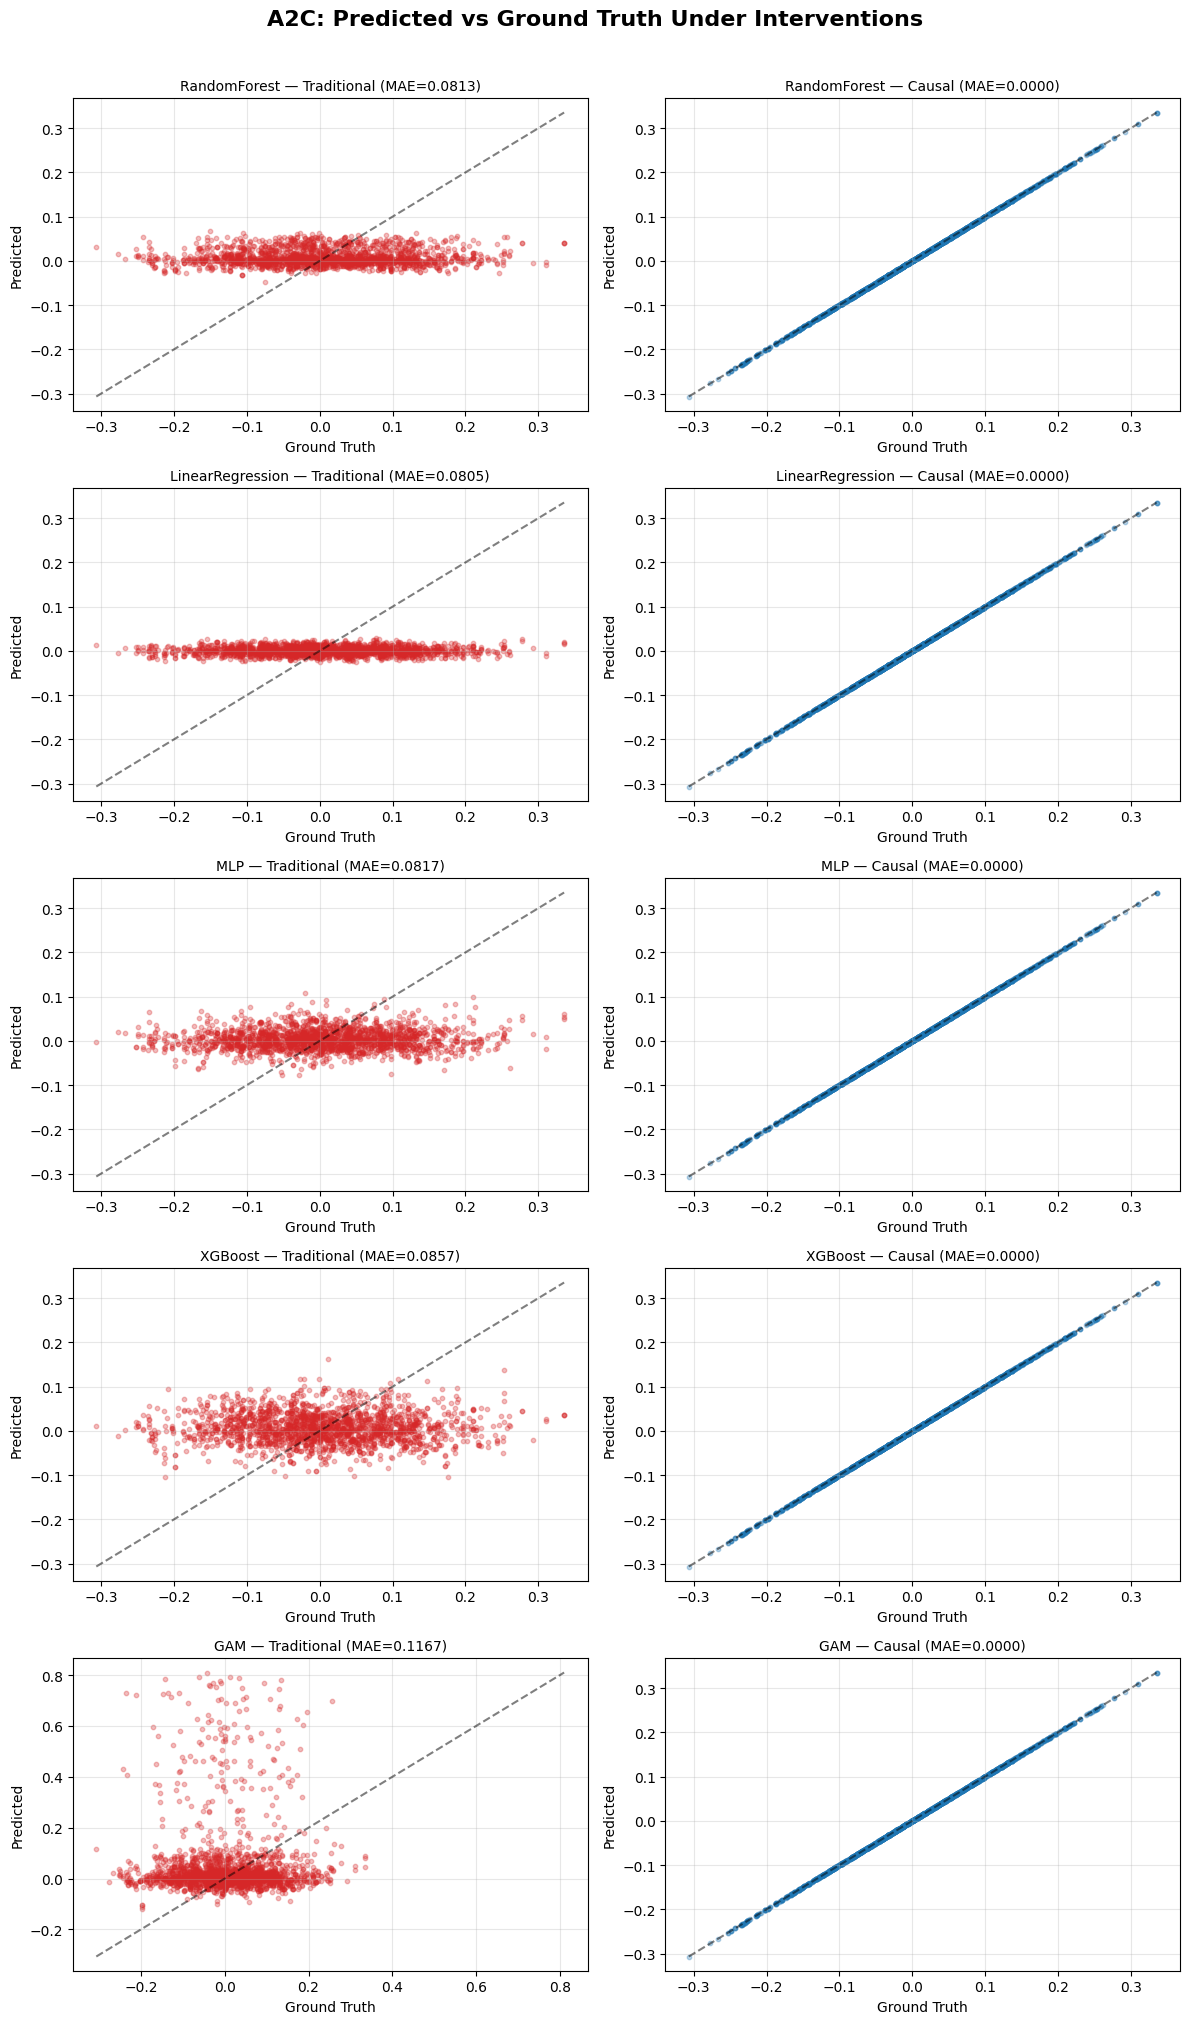

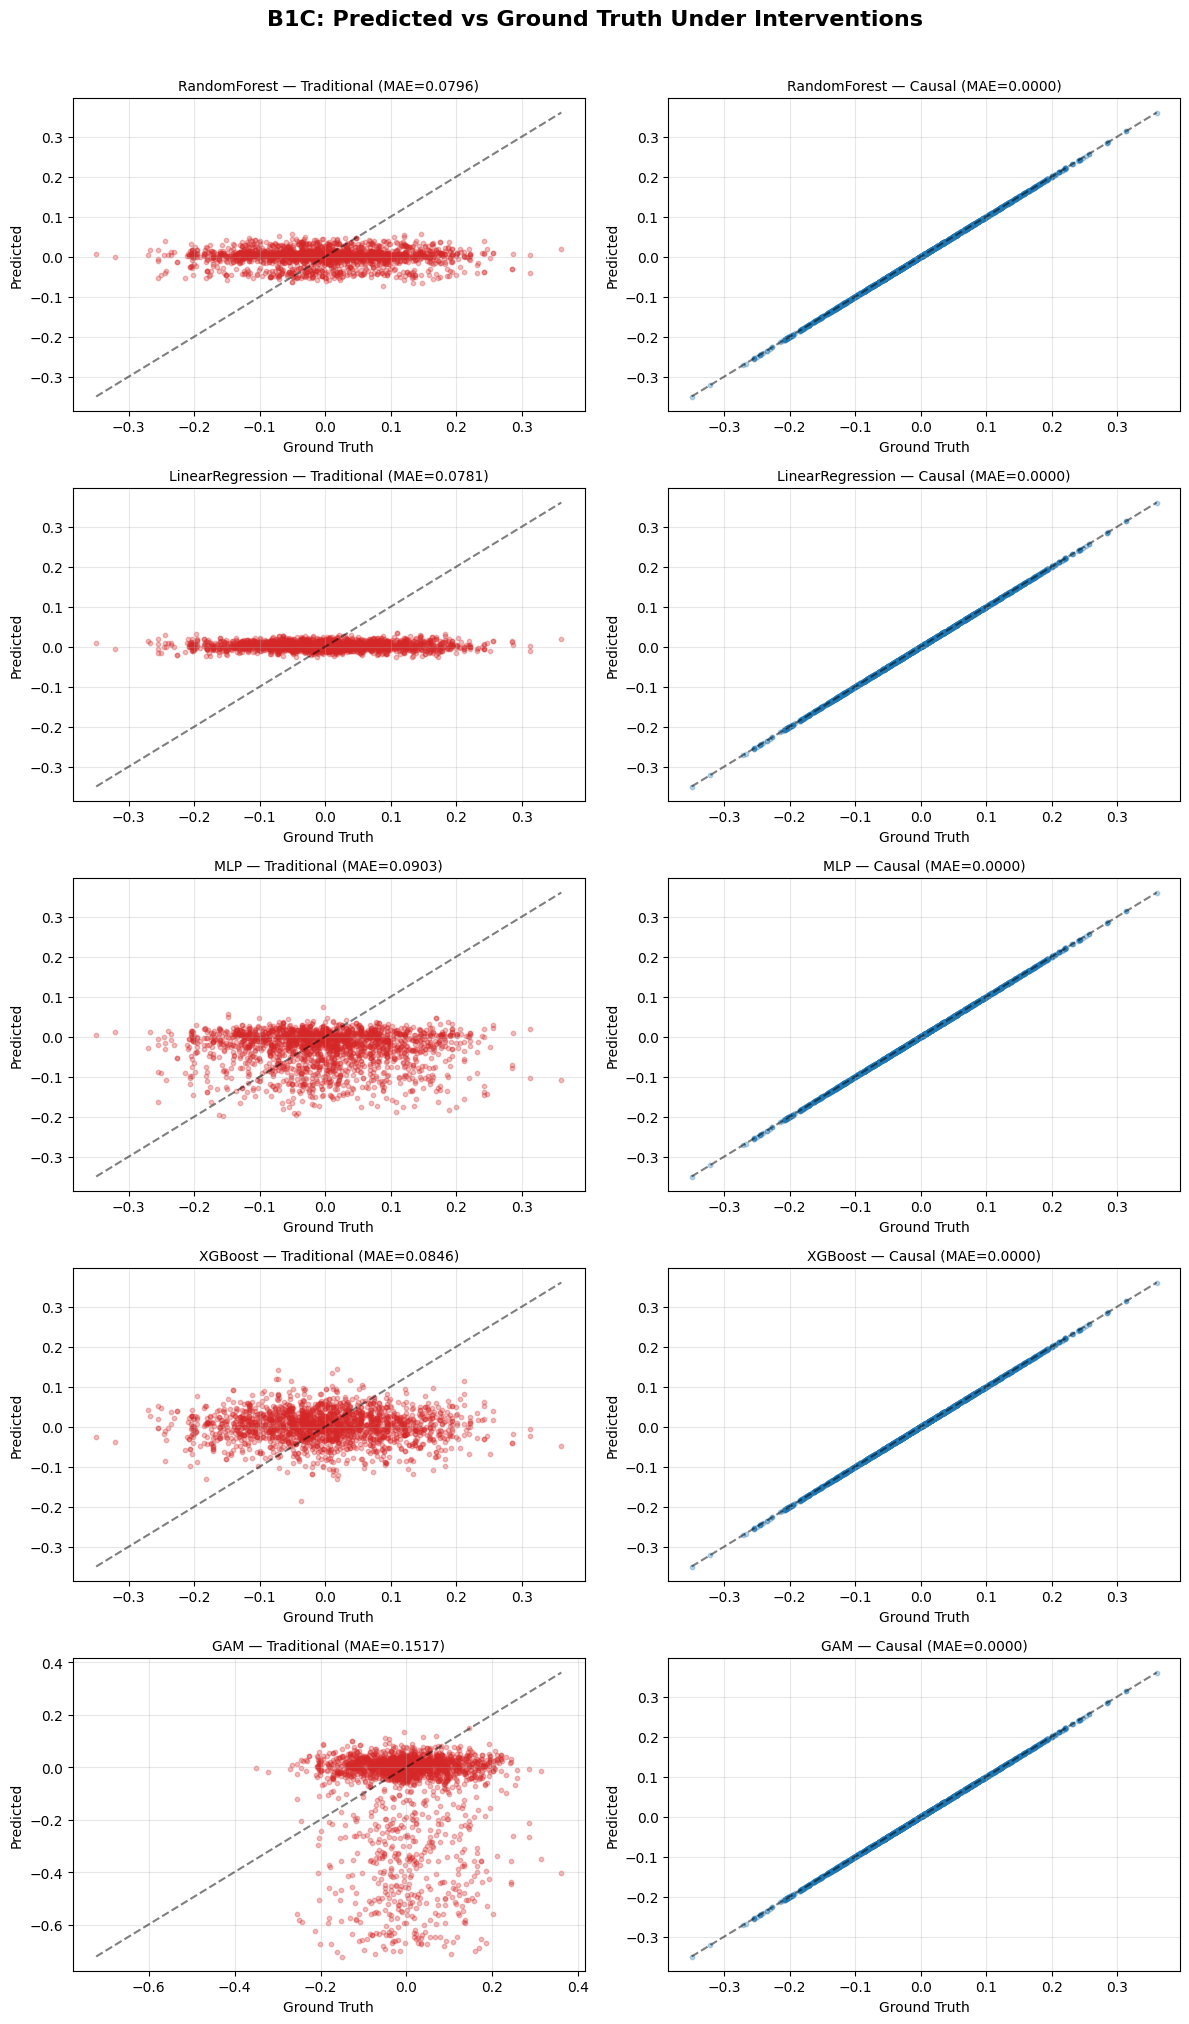

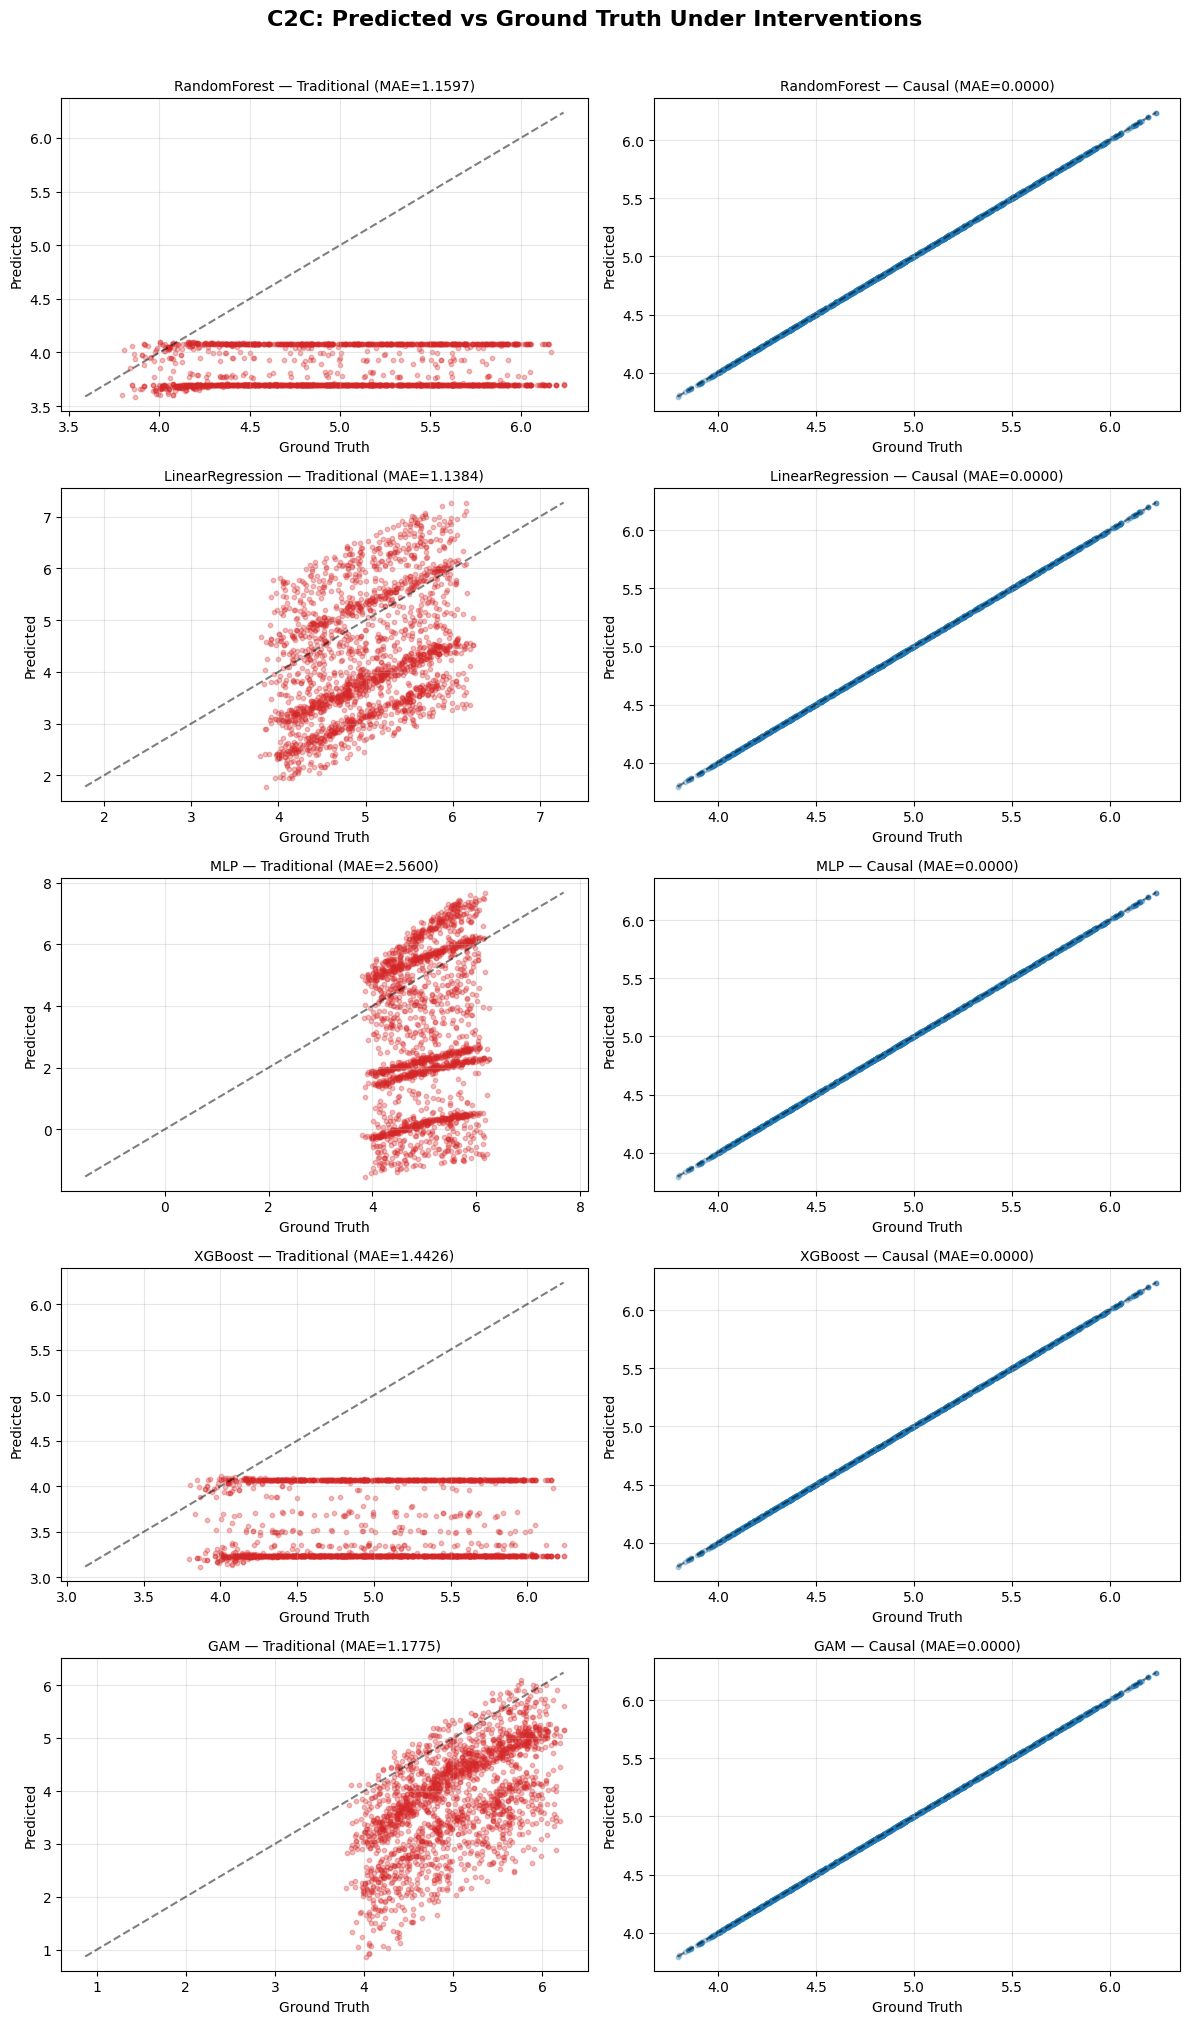

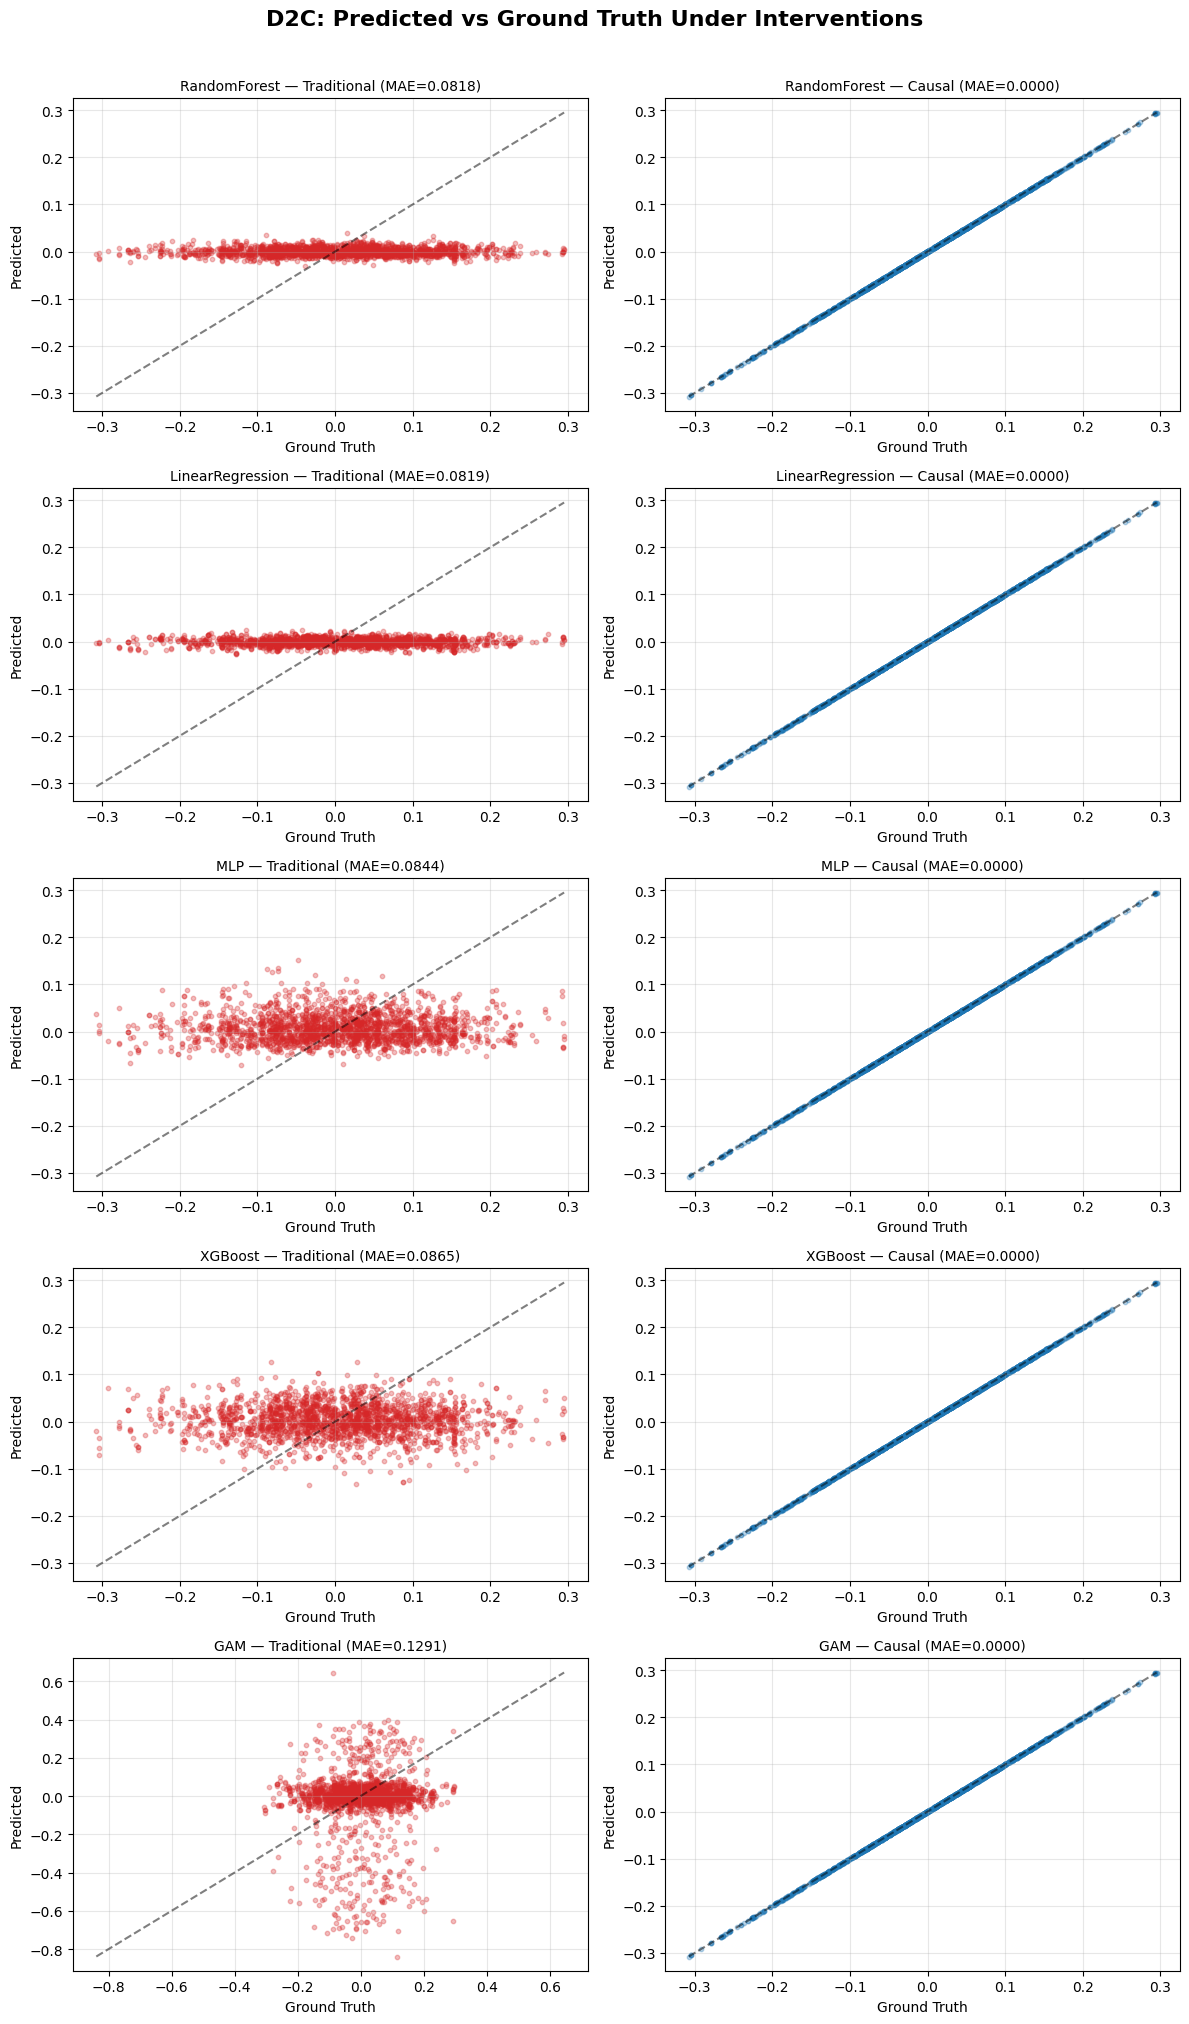

In [14]:
# --- 10a. Per-experiment scatter plots: Predicted vs Ground Truth ---
for exp_name in EXPERIMENTS.keys():
    exp_df = all_interv_records[exp_name]
    model_names = list(model_configs.keys())
    n_models = len(model_names)
    
    fig, axes = plt.subplots(n_models, 2, figsize=(12, 4 * n_models), squeeze=False)
    fig.suptitle(f'{exp_name}: Predicted vs Ground Truth Under Interventions',
                 fontsize=16, fontweight='bold', y=1.01)
    
    for i, mname in enumerate(model_names):
        mdf = exp_df[exp_df['algorithm'] == mname]
        gt = mdf['ground_truth'].values
        
        # Traditional
        ax = axes[i, 0]
        trad = mdf['traditional_pred'].values
        ax.scatter(gt, trad, alpha=0.3, s=10, color='tab:red')
        lims = [min(gt.min(), trad.min()), max(gt.max(), trad.max())]
        ax.plot(lims, lims, 'k--', alpha=0.5)
        mae_t = np.mean(np.abs(gt - trad))
        ax.set_title(f'{mname} — Traditional (MAE={mae_t:.4f})', fontsize=10)
        ax.set_xlabel('Ground Truth'); ax.set_ylabel('Predicted')
        ax.grid(True, alpha=0.3)
        
        # Causal
        ax = axes[i, 1]
        causal = mdf['causal_pred'].values
        ax.scatter(gt, causal, alpha=0.3, s=10, color='tab:blue')
        lims = [min(gt.min(), causal.min()), max(gt.max(), causal.max())]
        ax.plot(lims, lims, 'k--', alpha=0.5)
        mae_c = np.mean(np.abs(gt - causal))
        ax.set_title(f'{mname} — Causal (MAE={mae_c:.4f})', fontsize=10)
        ax.set_xlabel('Ground Truth'); ax.set_ylabel('Predicted')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

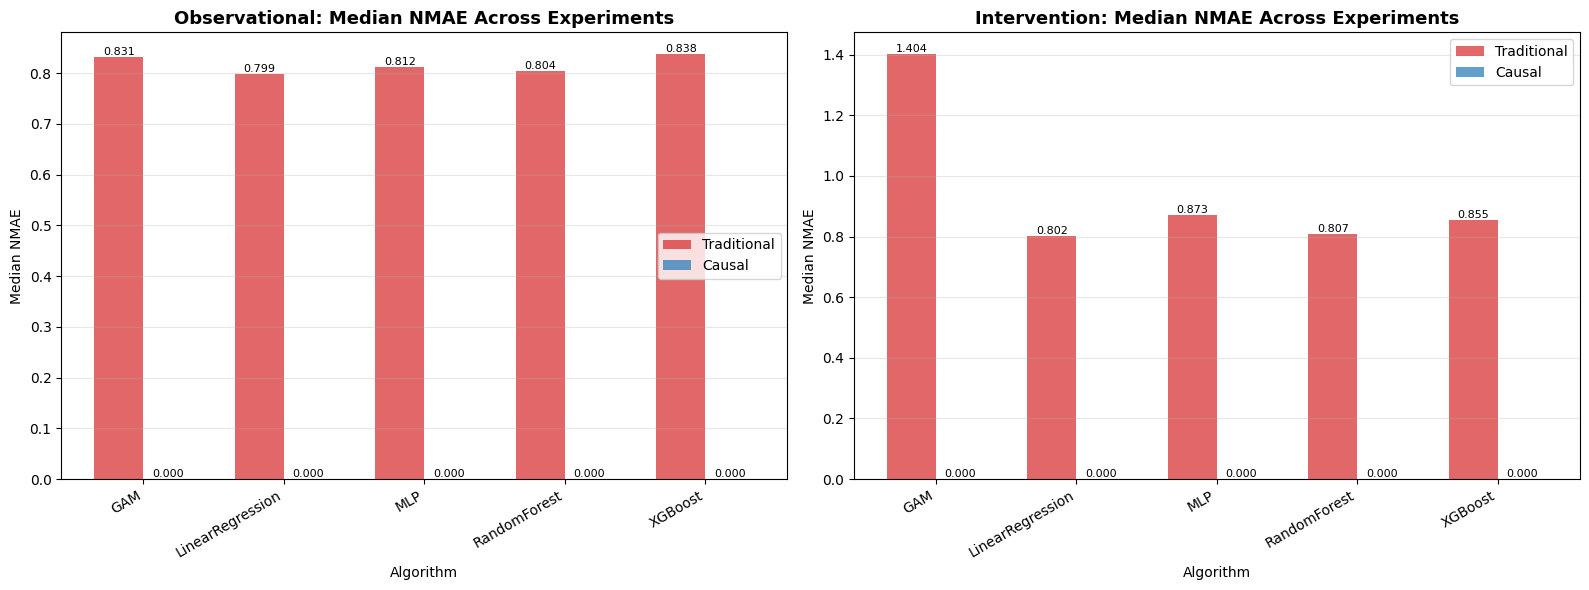

In [15]:
# --- 10b. Cross-experiment bar chart: Median NMAE per algorithm ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (title, df_plot) in enumerate([
    ('Observational', obs_median),
    ('Intervention', interv_median)
]):
    ax = axes[idx]
    algos = sorted(df_plot['Algorithm'].unique())
    x = np.arange(len(algos))
    width = 0.35
    
    trad_vals = [df_plot[(df_plot['Algorithm'] == a) & (df_plot['Model_Type'] == 'Traditional')]['Median_NMAE'].values[0]
                 for a in algos]
    causal_vals = [df_plot[(df_plot['Algorithm'] == a) & (df_plot['Model_Type'] == 'Causal')]['Median_NMAE'].values[0]
                   for a in algos]
    
    bars1 = ax.bar(x - width/2, trad_vals, width, label='Traditional', color='tab:red', alpha=0.7)
    bars2 = ax.bar(x + width/2, causal_vals, width, label='Causal', color='tab:blue', alpha=0.7)
    
    ax.set_xlabel('Algorithm')
    ax.set_ylabel('Median NMAE')
    ax.set_title(f'{title}: Median NMAE Across Experiments', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(algos, rotation=30, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

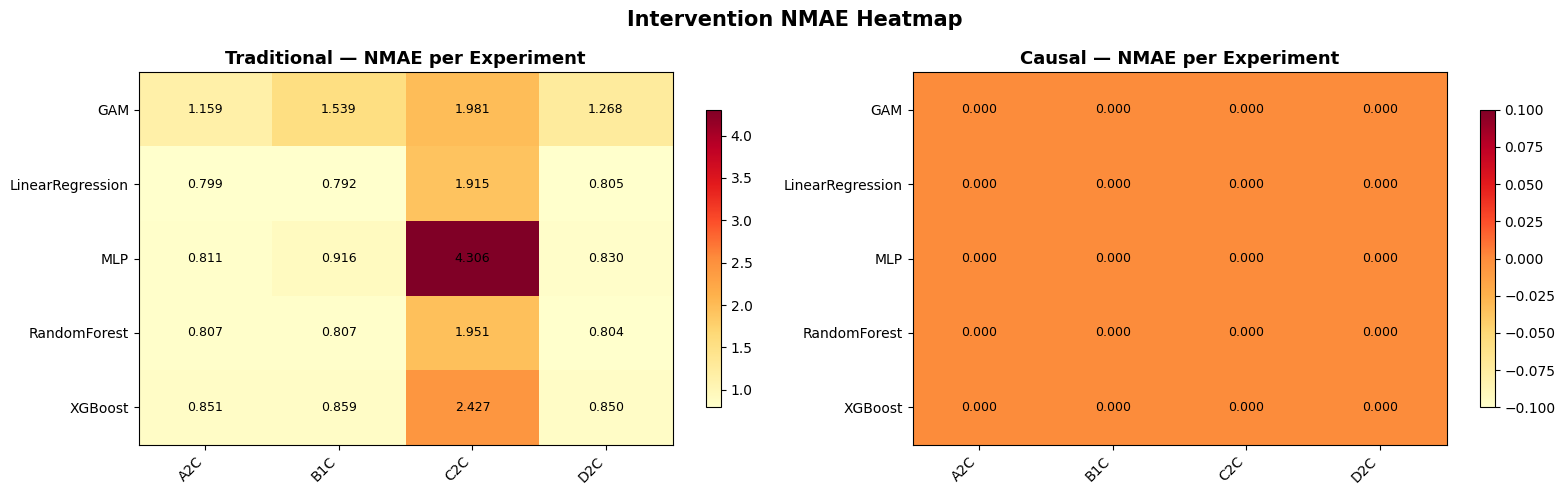

In [16]:
# --- 10c. Heatmap: NMAE per experiment × algorithm (Intervention) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, mtype in enumerate(['Traditional', 'Causal']):
    ax = axes[idx]
    sub = interv_df_all[interv_df_all['Model_Type'] == mtype]
    pivot = sub.pivot(index='Algorithm', columns='Experiment', values='NMAE')
    # Reorder experiments
    pivot = pivot[list(EXPERIMENTS.keys())]
    
    im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title(f'{mtype} — NMAE per Experiment', fontsize=13, fontweight='bold')
    
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            ax.text(j, i, f'{pivot.values[i, j]:.3f}', ha='center', va='center', fontsize=9)
    
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Intervention NMAE Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

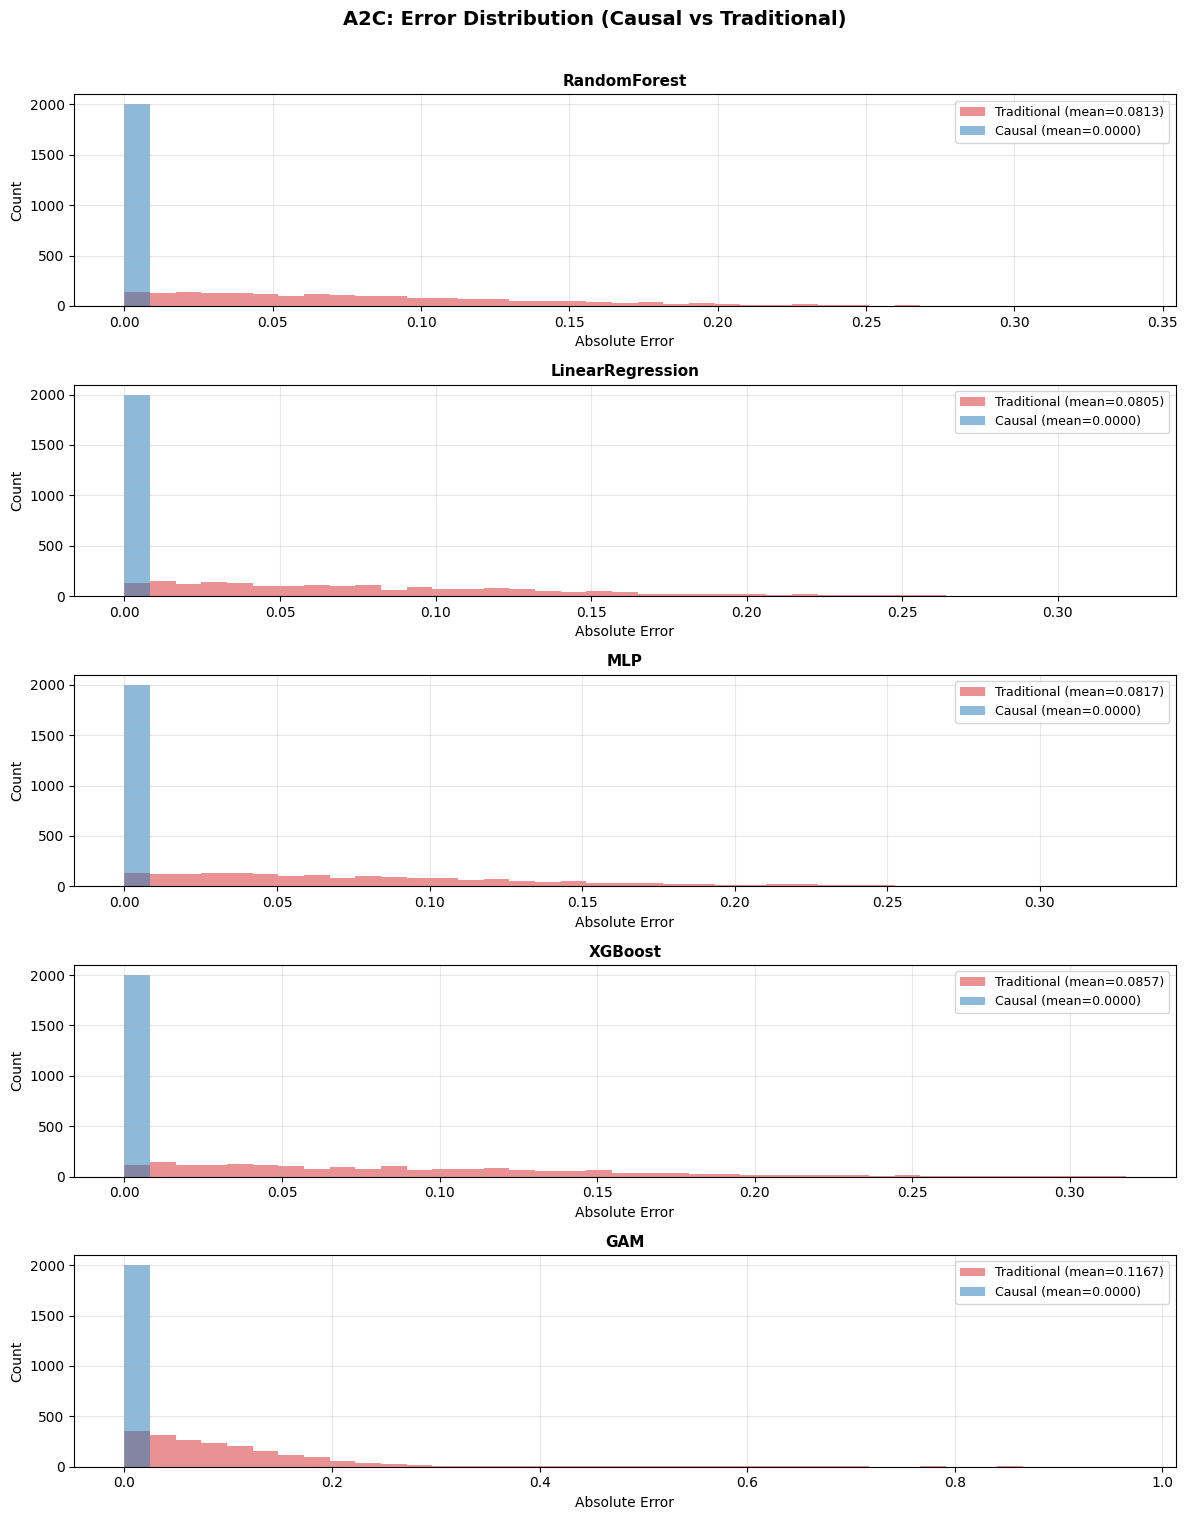

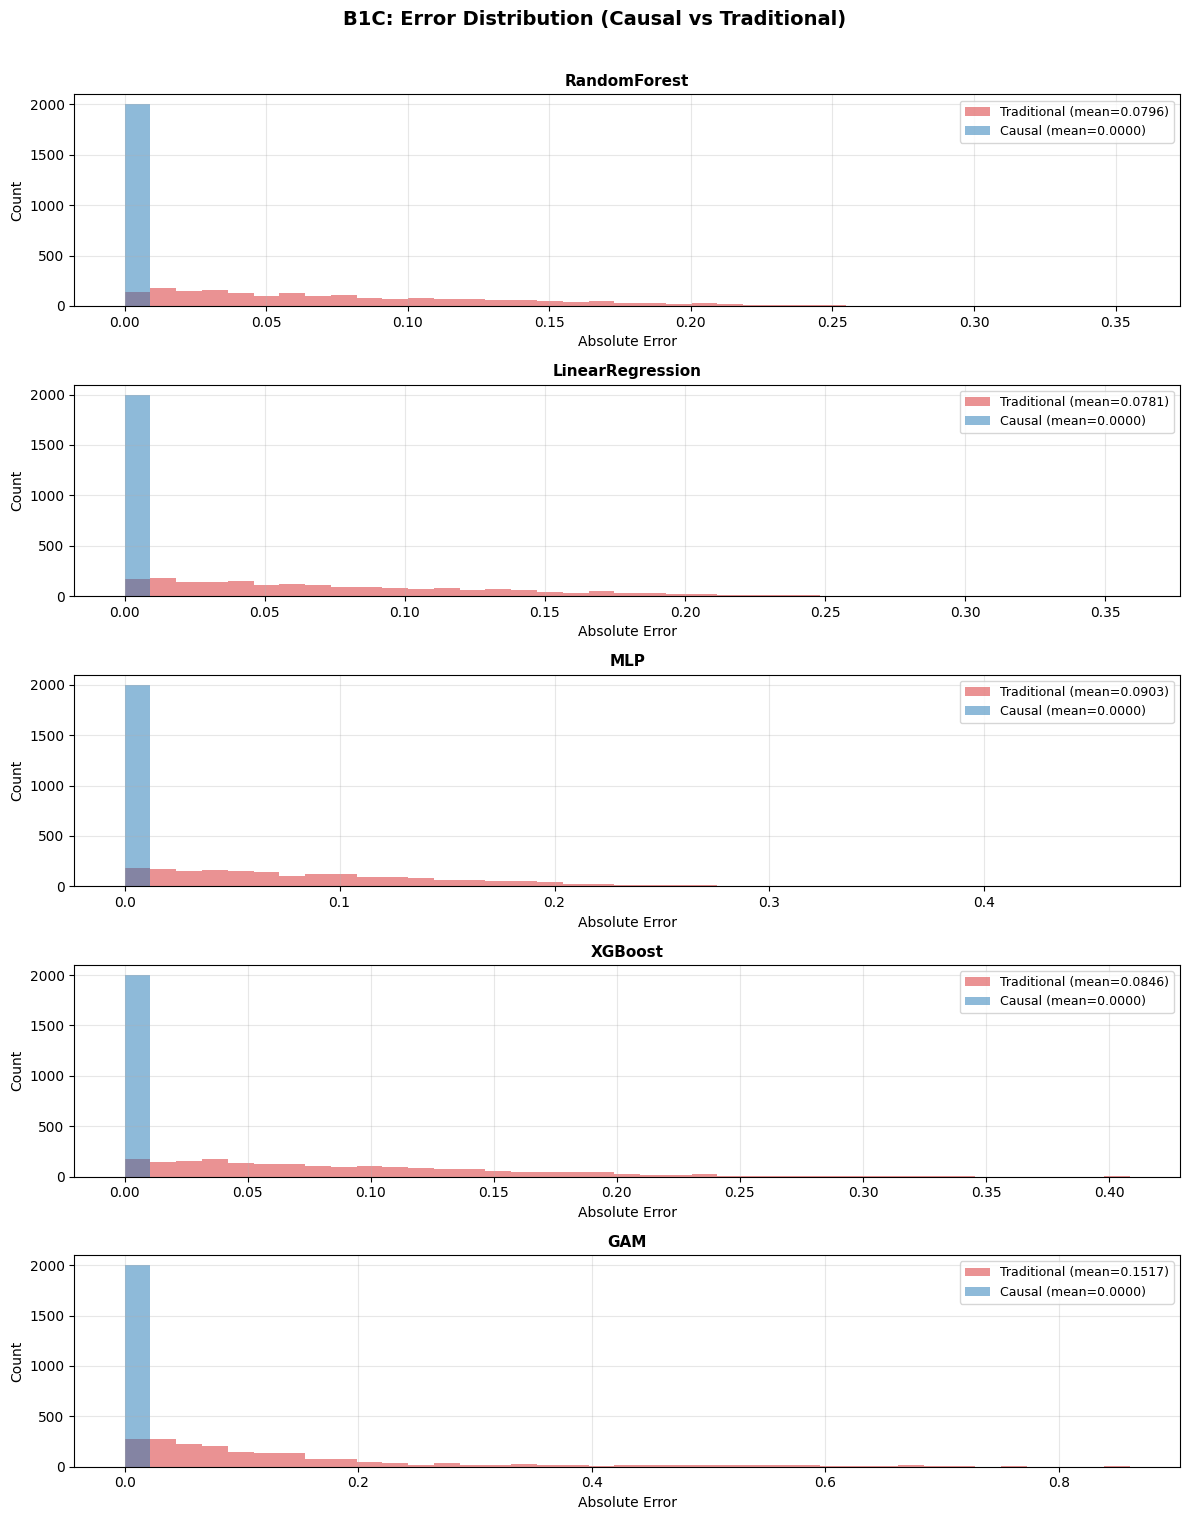

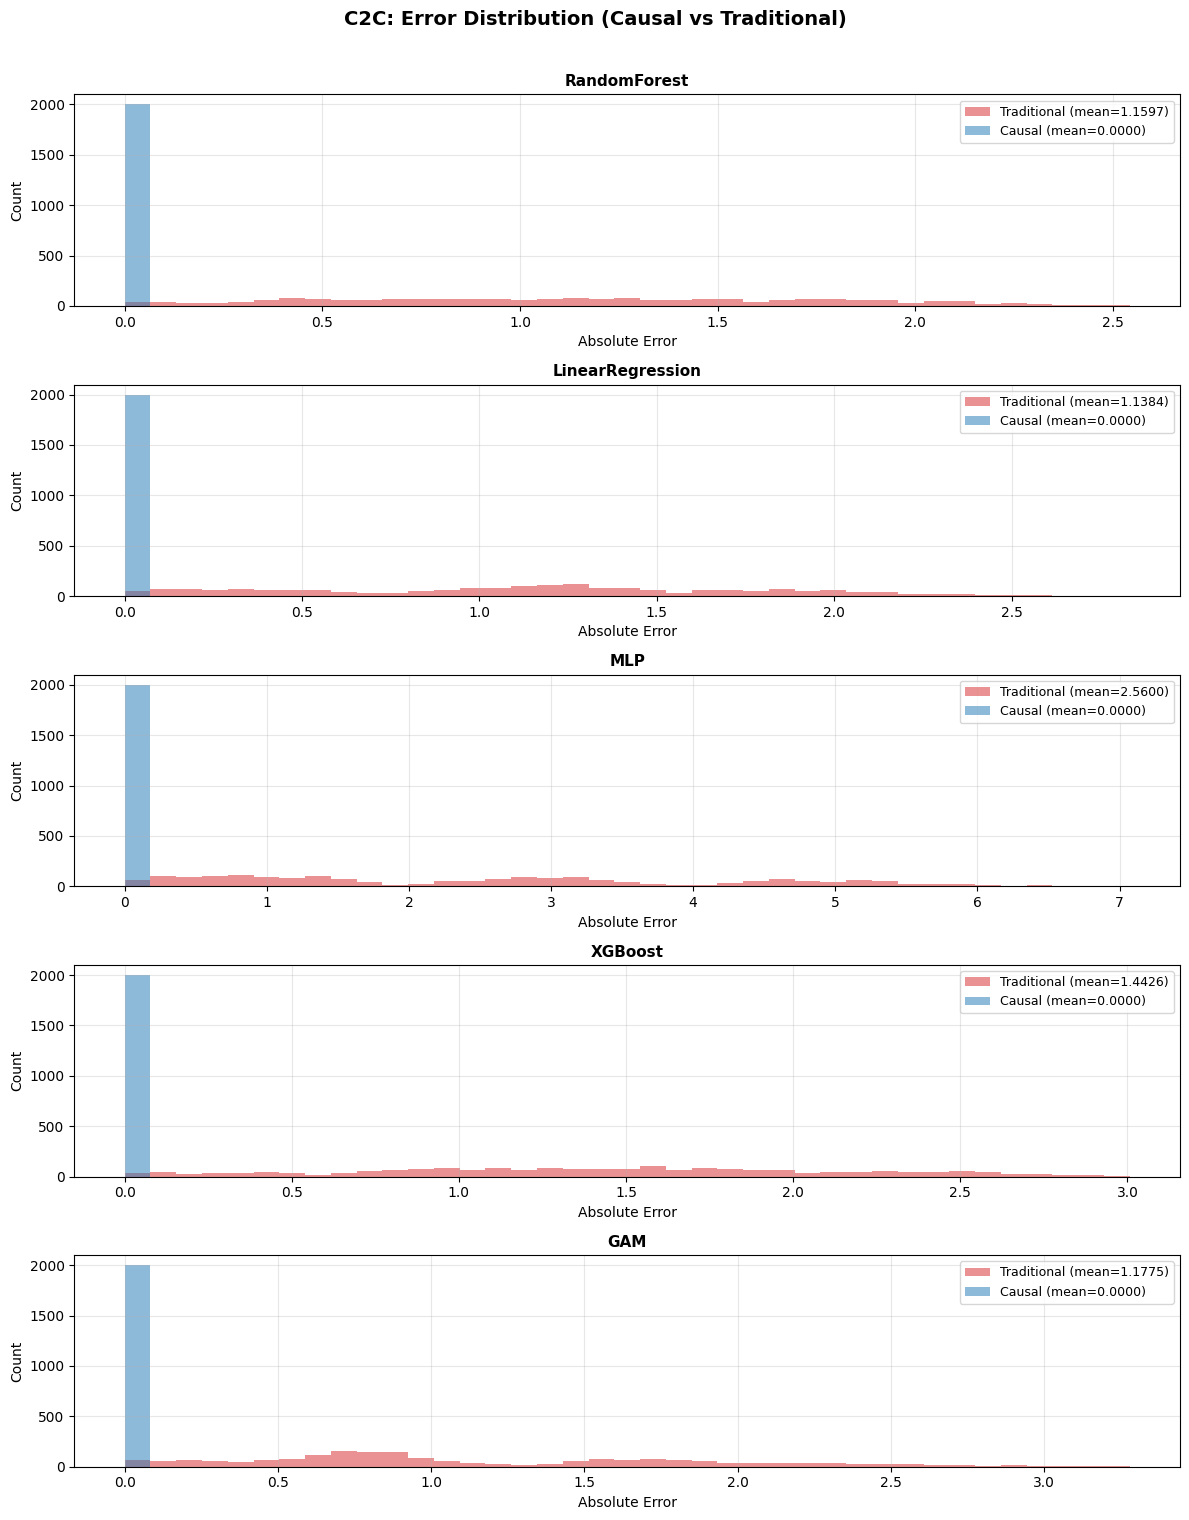

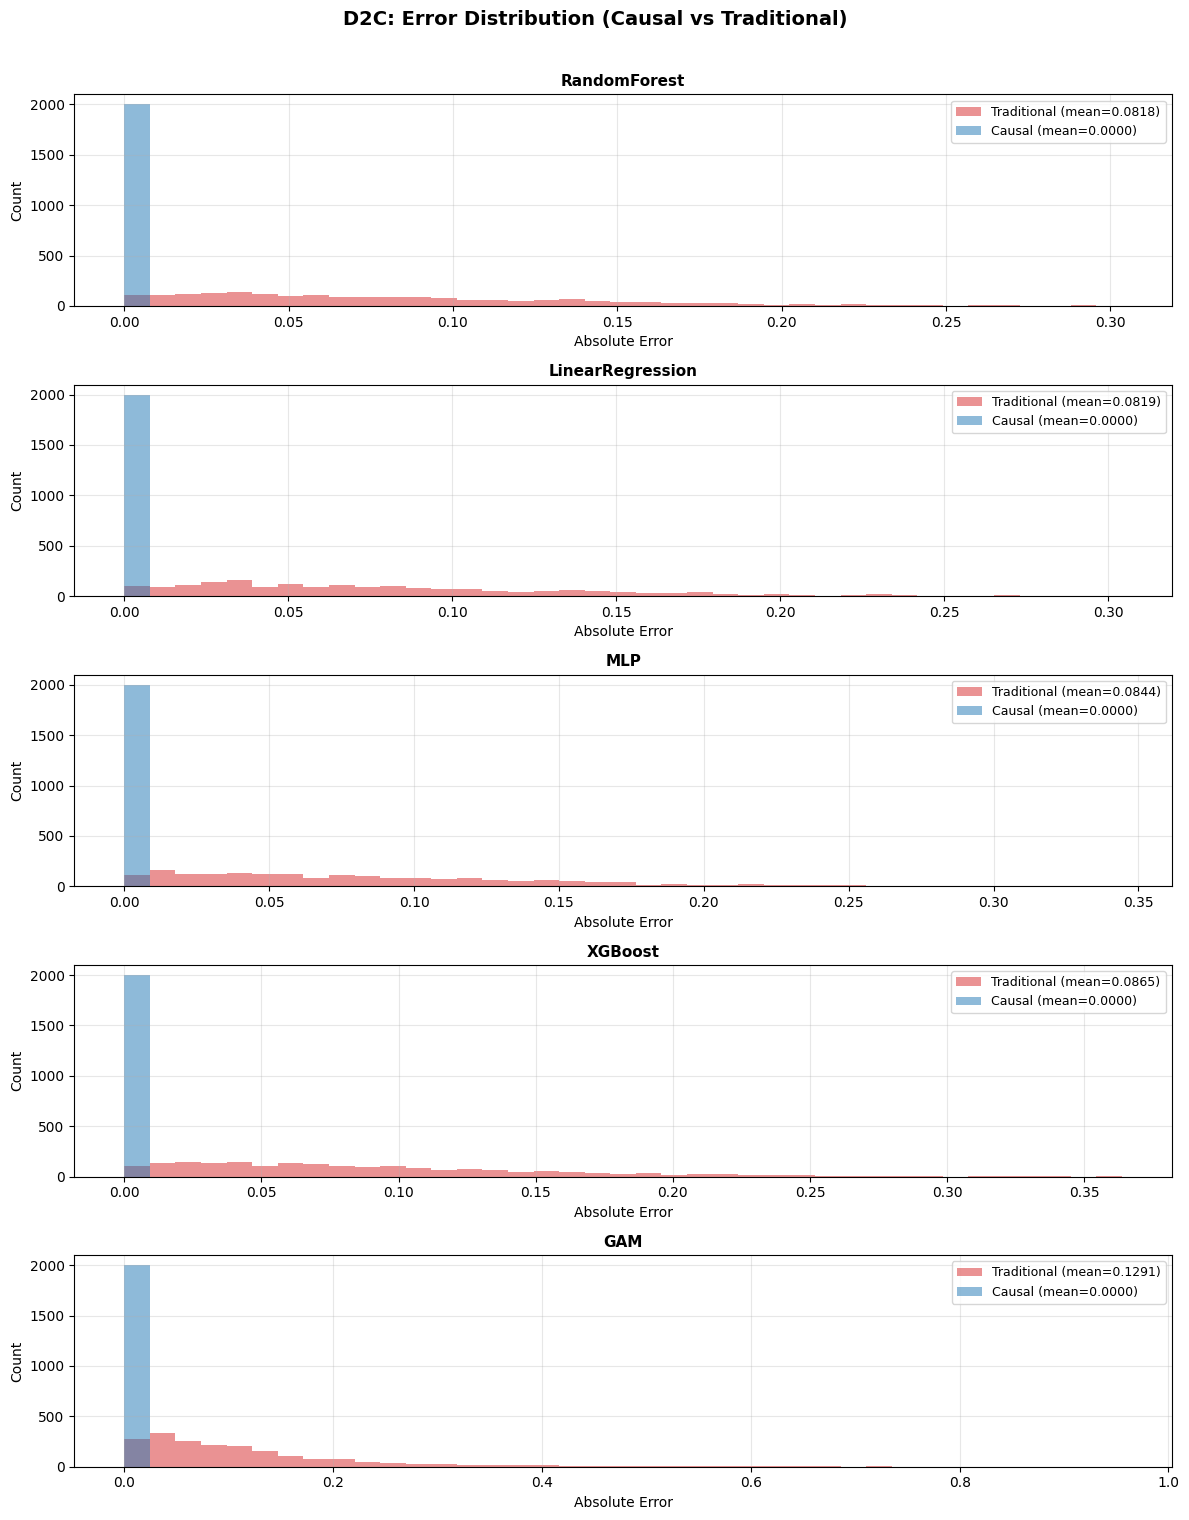

In [17]:
# --- 10d. Per-experiment error distributions ---
for exp_name in EXPERIMENTS.keys():
    exp_df = all_interv_records[exp_name]
    model_names = list(model_configs.keys())
    n_models = len(model_names)
    
    fig, axes = plt.subplots(n_models, 1, figsize=(12, 3 * n_models), squeeze=False)
    fig.suptitle(f'{exp_name}: Error Distribution (Causal vs Traditional)',
                 fontsize=14, fontweight='bold', y=1.01)
    
    for i, mname in enumerate(model_names):
        ax = axes[i, 0]
        mdf = exp_df[exp_df['algorithm'] == mname]
        max_err = max(mdf['traditional_error'].max(), mdf['causal_error'].max())
        bins = np.linspace(0, max_err, 40)
        
        ax.hist(mdf['traditional_error'], bins=bins, alpha=0.5, color='tab:red',
                label=f'Traditional (mean={mdf["traditional_error"].mean():.4f})')
        ax.hist(mdf['causal_error'], bins=bins, alpha=0.5, color='tab:blue',
                label=f'Causal (mean={mdf["causal_error"].mean():.4f})')
        ax.set_title(mname, fontsize=11, fontweight='bold')
        ax.set_xlabel('Absolute Error'); ax.set_ylabel('Count')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [18]:
# --- 10e. Final summary ---
print("\n" + "="*80)
print("FINAL SUMMARY: MEDIAN NORMALIZED METRICS ACROSS ALL EXPERIMENTS")
print("="*80)

print("\n--- Observational (Test Set) ---")
print(obs_median.to_string(index=False))

print("\n--- Interventional ---")
print(interv_median.to_string(index=False))

print("\n--- Causal Improvement (Interventions) ---")
print(pivot_interv.to_string())

# Overall winner
best_causal = interv_median[interv_median['Model_Type'] == 'Causal'].sort_values('Median_NMAE').iloc[0]
best_trad = interv_median[interv_median['Model_Type'] == 'Traditional'].sort_values('Median_NMAE').iloc[0]

print(f"\nBest Causal: {best_causal['Algorithm']} (Median NMAE={best_causal['Median_NMAE']:.4f})")
print(f"Best Traditional: {best_trad['Algorithm']} (Median NMAE={best_trad['Median_NMAE']:.4f})")


FINAL SUMMARY: MEDIAN NORMALIZED METRICS ACROSS ALL EXPERIMENTS

--- Observational (Test Set) ---
 Model_Type        Algorithm  Median_NMAE  Median_NRMSE  Mean_NMAE  Mean_NRMSE
     Causal              GAM     0.000000      0.000000   0.000000    0.000000
     Causal LinearRegression     0.000000      0.000000   0.000000    0.000000
     Causal              MLP     0.000000      0.000000   0.000000    0.000000
     Causal     RandomForest     0.000000      0.000000   0.000000    0.000000
     Causal          XGBoost     0.000000      0.000000   0.000000    0.000000
Traditional LinearRegression     0.798772      1.002222   0.634799    0.795656
Traditional     RandomForest     0.803606      1.005619   0.995812    1.217555
Traditional              MLP     0.811803      1.017744   0.645529    0.810876
Traditional              GAM     0.831408      1.041391   0.731340    0.927332
Traditional          XGBoost     0.838315      1.052720   1.026510    1.255421

--- Interventional ---
 Model_T